# Lab 3: Contextual Bandit-Based News Article Recommendation



# Imports and Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from rlcmab_sampler import sampler

import warnings
warnings.filterwarnings('ignore')

# Load Datasets

In [ ]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [ ]:
# --- Data Preprocessing ---

# Explore the datasets
print("=== Train Users ===")
print(f"Shape: {train_users.shape}")
print(f"Labels: {train_users['label'].value_counts().to_dict()}")
print(f"\nMissing values:\n{train_users.isnull().sum()[train_users.isnull().sum() > 0]}")

print("\n=== Test Users ===")
print(f"Shape: {test_users.shape}")
print(f"\nMissing values:\n{test_users.isnull().sum()[test_users.isnull().sum() > 0]}")

print("\n=== News Articles ===")
print(f"Shape: {news_df.shape}")
print(f"Categories: {news_df['category'].nunique()}")
print(news_df['category'].value_counts())

=== Train Users ===
Shape: (2000, 33)
Labels: {'user_2': 712, 'user_1': 707, 'user_3': 581}

Missing values:
age    698
dtype: int64

=== Test Users ===
Shape: (2000, 32)

Missing values:
age    679
dtype: int64

=== News Articles ===
Shape: (209527, 6)
Categories: 42
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TA

In [ ]:
# --- Feature Engineering & Cleaning ---

# Columns to drop (non-predictive identifiers and problematic string columns)
drop_cols = ['user_id', 'browser_version']

# Separate features and labels for train
y_train_full = train_users['label'].copy()
X_train_full = train_users.drop(columns=['label'] + drop_cols, errors='ignore')
X_test_final = test_users.drop(columns=drop_cols, errors='ignore')

# Encode categorical columns
# 'region_code' - categorical
# 'subscriber' - boolean
le_region = LabelEncoder()
all_regions = pd.concat([X_train_full['region_code'], X_test_final['region_code']]).astype(str)
le_region.fit(all_regions)
X_train_full['region_code'] = le_region.transform(X_train_full['region_code'].astype(str))
X_test_final['region_code'] = le_region.transform(X_test_final['region_code'].astype(str))

# Encode subscriber as int
X_train_full['subscriber'] = X_train_full['subscriber'].astype(int)
X_test_final['subscriber'] = X_test_final['subscriber'].astype(int)

# Encode labels
le_label = LabelEncoder()
le_label.fit(['user_1', 'user_2', 'user_3'])
y_train_encoded = le_label.transform(y_train_full)

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_full),
    columns=X_train_full.columns,
    index=X_train_full.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_final),
    columns=X_test_final.columns,
    index=X_test_final.index
)

print(f"Training features shape: {X_train_imputed.shape}")
print(f"Test features shape: {X_test_imputed.shape}")
print(f"Label distribution:\n{pd.Series(y_train_full).value_counts()}")
print(f"\nFeatures used: {list(X_train_imputed.columns)}")

Training features shape: (2000, 30)
Test features shape: (2000, 30)
Label distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64

Features used: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'background_app_count', 'session_inactivity_duration', 'network_jitter', 'region_code', 'subscriber']


## User Classification



In [ ]:
# --- Train/Validation Split & Model Training ---

# Split training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_imputed, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded
)

# Train a Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

# Validation accuracy
y_val_pred = rf_clf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy (Random Forest): {val_acc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_val, y_val_pred, target_names=le_label.classes_)}")

# Cross-validation on full training set
cv_scores = cross_val_score(rf_clf, X_train_imputed, y_train_encoded, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Individual fold scores: {cv_scores}")

Validation Accuracy (Random Forest): 0.9000

Classification Report:
              precision    recall  f1-score   support

      user_1       0.90      0.86      0.88       142
      user_2       0.97      0.88      0.92       142
      user_3       0.84      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400

5-Fold Cross-Validation Accuracy: 0.8895 (+/- 0.0142)
Individual fold scores: [0.87   0.91   0.9    0.88   0.8875]


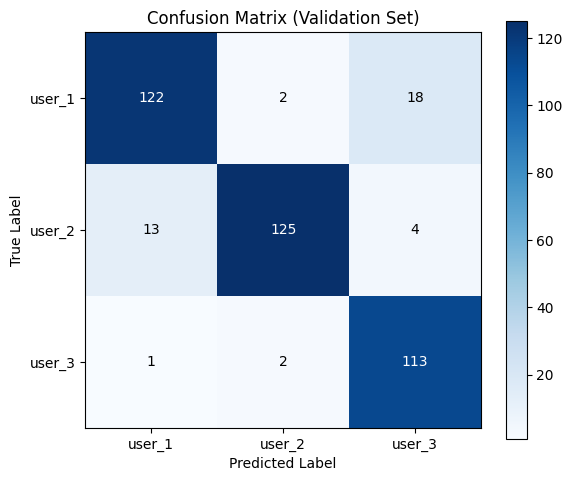

In [ ]:
# --- Confusion Matrix Visualization ---

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=le_label.classes_,
       yticklabels=le_label.classes_,
       title='Confusion Matrix (Validation Set)',
       xlabel='Predicted Label',
       ylabel='True Label')

# Add text annotations
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

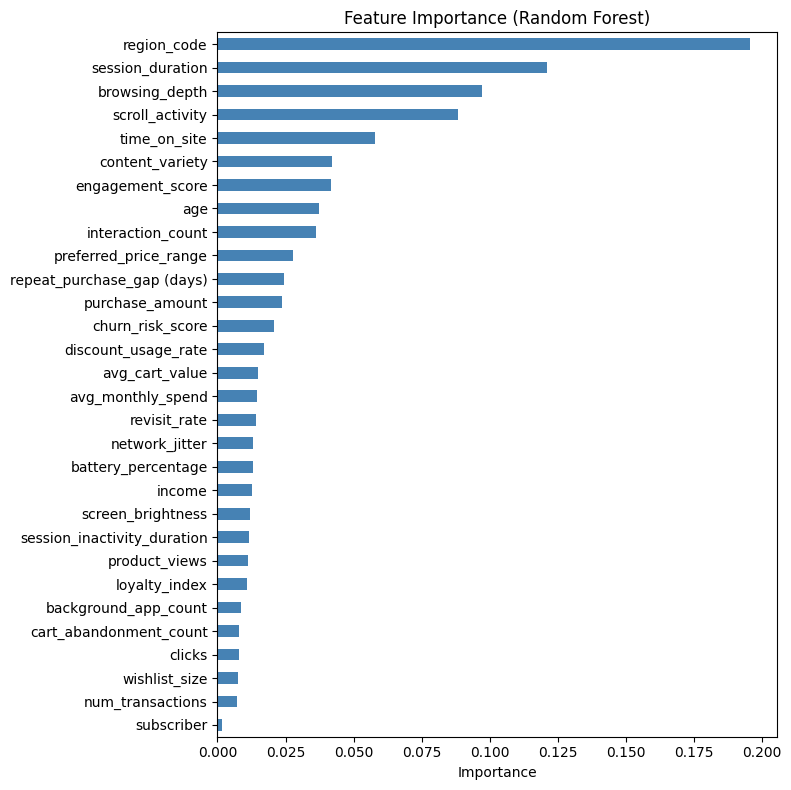

In [ ]:
# --- Feature Importance ---

importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=X_train_imputed.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# --- Predict on Test Users (Context for Bandit) ---

# Retrain on full training data for best predictions
rf_final = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X_train_imputed, y_train_encoded)

# Predict user categories for test set
test_pred_encoded = rf_final.predict(X_test_imputed)
test_pred_labels = le_label.inverse_transform(test_pred_encoded)

# Add predictions to test dataframe
test_users['predicted_label'] = test_pred_labels

print("=== Test User Predictions ===")
print(f"Predicted label distribution:\n{pd.Series(test_pred_labels).value_counts()}")
print(f"\nSample predictions:")
print(test_users[['user_id', 'predicted_label']].head(10))

=== Test User Predictions ===
Predicted label distribution:
user_2    693
user_1    677
user_3    630
Name: count, dtype: int64

Sample predictions:
  user_id predicted_label
0   U4058          user_2
1   U1118          user_1
2   U6555          user_1
3   U9170          user_1
4   U3348          user_1
5   U2244          user_3
6   U3022          user_3
7   U5291          user_1
8   U1945          user_3
9   U6084          user_3


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i = 20230113`.
Rewards are obtained using `sampler.sample(j)` where `j ∈ {0, 1, ..., 11}`.

Each arm corresponds to a **(user_type, news_category)** pair:
- **User 1** → Arms 0–3
- **User 2** → Arms 4–7
- **User 3** → Arms 8–11

Within each user, the 4 arms map to: Entertainment, Education, Tech, Crime.

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [ ]:
# --- Sampler Initialization and Arm Mapping ---

# Initialize sampler with roll number
roll_number = 20230113
reward_sampler = sampler(roll_number)

# Define the arm mapping
# Arms 0-3: User1 x [Entertainment, Education, Tech, Crime]
# Arms 4-7: User2 x [Entertainment, Education, Tech, Crime]
# Arms 8-11: User3 x [Entertainment, Education, Tech, Crime]

categories = ['Entertainment', 'Education', 'Tech', 'Crime']
user_types = ['user_1', 'user_2', 'user_3']

# Map (user_type, category_index) -> arm_index
def get_arm_index(user_type, category_idx):
    """Convert user type and category index to bandit arm index."""
    user_offset = user_types.index(user_type) * len(categories)
    return user_offset + category_idx

# Map arm_index -> (user_type, category)
def get_arm_info(arm_idx):
    """Convert arm index to (user_type, category) tuple."""
    user_idx = arm_idx // len(categories)
    cat_idx = arm_idx % len(categories)
    return user_types[user_idx], categories[cat_idx]

# Number of arms per user context
n_arms_per_user = len(categories)  # 4
n_total_arms = len(user_types) * len(categories)  # 12

# Print arm mapping table
print("=" * 50)
print("ARM INDEX MAPPING")
print("=" * 50)
print(f"{'Arm j':<8} {'User Context':<12} {'News Category':<15}")
print("-" * 50)
for j in range(n_total_arms):
    u, c = get_arm_info(j)
    print(f"{j:<8} {u:<12} {c:<15}")

# Quick test: sample a few rewards
print(f"\nSample rewards from arm 0: {[round(reward_sampler.sample(0), 3) for _ in range(5)]}")
print(f"Sample rewards from arm 5: {[round(reward_sampler.sample(5), 3) for _ in range(5)]}")

# Count test users per predicted category
print(f"\n=== Test User Contexts ===")
print(test_users['predicted_label'].value_counts())

ARM INDEX MAPPING
Arm j    User Context News Category  
--------------------------------------------------
0        user_1       Entertainment  
1        user_1       Education      
2        user_1       Tech           
3        user_1       Crime          
4        user_2       Entertainment  
5        user_2       Education      
6        user_2       Tech           
7        user_2       Crime          
8        user_3       Entertainment  
9        user_3       Education      
10       user_3       Tech           
11       user_3       Crime          

Sample rewards from arm 0: [np.float64(-6.191), np.float64(-4.132), np.float64(-3.282), np.float64(-4.378), np.float64(-3.237)]
Sample rewards from arm 5: [np.float64(1.58), np.float64(-0.563), np.float64(2.287), np.float64(-0.452), np.float64(-0.229)]

=== Test User Contexts ===
predicted_label
user_2    693
user_1    677
user_3    630
Name: count, dtype: int64


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [ ]:
# --- Epsilon-Greedy Contextual Bandit ---

class EpsilonGreedy:
    """
    Epsilon-Greedy strategy for contextual bandits.

    With probability epsilon, explore (pick a random arm for that context).
    With probability 1-epsilon, exploit (pick the arm with highest estimated reward).
    """

    def __init__(self, n_users, n_arms_per_user, epsilon=0.1):
        self.n_users = n_users
        self.n_arms = n_arms_per_user
        self.epsilon = epsilon
        # Q-values: estimated reward for each (user, arm) pair
        self.Q = np.zeros((n_users, n_arms_per_user))
        # Count of times each (user, arm) was selected
        self.N = np.zeros((n_users, n_arms_per_user))

    def select_arm(self, user_idx):
        """Select an arm for the given user context."""
        if np.random.random() < self.epsilon:
            # Explore: random arm
            return np.random.randint(self.n_arms)
        else:
            # Exploit: best estimated arm (break ties randomly)
            q_values = self.Q[user_idx]
            max_q = np.max(q_values)
            best_arms = np.where(q_values == max_q)[0]
            return np.random.choice(best_arms)

    def update(self, user_idx, arm_idx, reward):
        """Update Q-value estimate using incremental mean."""
        self.N[user_idx, arm_idx] += 1
        n = self.N[user_idx, arm_idx]
        self.Q[user_idx, arm_idx] += (reward - self.Q[user_idx, arm_idx]) / n

print("EpsilonGreedy class defined successfully.")
print(f"Parameters: epsilon controls exploration rate.")
print(f"  - epsilon=0 → pure exploitation (greedy)")
print(f"  - epsilon=1 → pure exploration (random)")
print(f"  - epsilon=0.1 → 10% exploration, 90% exploitation")

EpsilonGreedy class defined successfully.
Parameters: epsilon controls exploration rate.
  - epsilon=0 → pure exploitation (greedy)
  - epsilon=1 → pure exploration (random)
  - epsilon=0.1 → 10% exploration, 90% exploitation


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [ ]:
# --- Upper Confidence Bound (UCB) Contextual Bandit ---

class UCB:
    """
    Upper Confidence Bound (UCB1) strategy for contextual bandits.

    Selects the arm with the highest upper confidence bound:
        UCB(a) = Q(a) + c * sqrt(ln(t) / N(a))

    where c is the exploration parameter controlling the confidence width.
    """

    def __init__(self, n_users, n_arms_per_user, c=2.0):
        self.n_users = n_users
        self.n_arms = n_arms_per_user
        self.c = c
        self.Q = np.zeros((n_users, n_arms_per_user))
        self.N = np.zeros((n_users, n_arms_per_user))
        self.t = np.zeros(n_users)  # total pulls per user context

    def select_arm(self, user_idx):
        """Select an arm using UCB1 formula."""
        self.t[user_idx] += 1

        # If any arm hasn't been tried, pick it first
        untried = np.where(self.N[user_idx] == 0)[0]
        if len(untried) > 0:
            return np.random.choice(untried)

        # UCB1 formula
        ucb_values = self.Q[user_idx] + self.c * np.sqrt(
            np.log(self.t[user_idx]) / self.N[user_idx]
        )
        return np.argmax(ucb_values)

    def update(self, user_idx, arm_idx, reward):
        """Update Q-value estimate using incremental mean."""
        self.N[user_idx, arm_idx] += 1
        n = self.N[user_idx, arm_idx]
        self.Q[user_idx, arm_idx] += (reward - self.Q[user_idx, arm_idx]) / n

print("UCB class defined successfully.")
print(f"Parameters: c controls exploration bonus width.")
print(f"  - Higher c → more exploration")
print(f"  - Lower c → faster convergence to exploitation")
print(f"  - c=2 is the standard UCB1 setting")

UCB class defined successfully.
Parameters: c controls exploration bonus width.
  - Higher c → more exploration
  - Lower c → faster convergence to exploitation
  - c=2 is the standard UCB1 setting


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [ ]:
# --- SoftMax (Boltzmann Exploration) Contextual Bandit ---

class SoftMax:
    """
    SoftMax (Boltzmann) exploration strategy for contextual bandits.

    Selects arms with probability proportional to:
        P(a) = exp(Q(a) / tau) / sum_b exp(Q(b) / tau)

    where tau (temperature) controls exploration:
        - High tau → uniform (more exploration)
        - Low tau → greedy (more exploitation)
    """

    def __init__(self, n_users, n_arms_per_user, tau=1.0):
        self.n_users = n_users
        self.n_arms = n_arms_per_user
        self.tau = tau
        self.Q = np.zeros((n_users, n_arms_per_user))
        self.N = np.zeros((n_users, n_arms_per_user))

    def select_arm(self, user_idx):
        """Select an arm using Boltzmann distribution."""
        q = self.Q[user_idx]
        # Numerical stability: subtract max
        q_scaled = (q - np.max(q)) / self.tau
        exp_q = np.exp(q_scaled)
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(self.n_arms, p=probs)

    def update(self, user_idx, arm_idx, reward):
        """Update Q-value estimate using incremental mean."""
        self.N[user_idx, arm_idx] += 1
        n = self.N[user_idx, arm_idx]
        self.Q[user_idx, arm_idx] += (reward - self.Q[user_idx, arm_idx]) / n

print("SoftMax class defined successfully.")
print(f"Parameters: tau (temperature) controls exploration.")
print(f"  - tau→∞ → uniform random selection")
print(f"  - tau→0 → greedy selection")
print(f"  - tau=1.0 → balanced exploration/exploitation")

SoftMax class defined successfully.
Parameters: tau (temperature) controls exploration.
  - tau→∞ → uniform random selection
  - tau→0 → greedy selection
  - tau=1.0 → balanced exploration/exploitation


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [ ]:
# --- Simulation Engine ---

def run_bandit_simulation(agent, reward_sampler, test_users_df, T=10000):
    """
    Run a contextual bandit simulation for T steps.

    At each step:
    1. A test user is sampled uniformly at random
    2. The user's predicted category determines the context
    3. The agent selects an arm (news category) for that context
    4. The reward is sampled from the sampler using the global arm index
    5. The agent updates its estimates

    Returns:
        rewards: array of rewards at each step
        arms_chosen: array of arms chosen at each step
        contexts: array of user contexts at each step
        cumulative_avg_rewards: running average reward
        per_context_rewards: dict of rewards per context
    """
    rewards = np.zeros(T)
    arms_chosen = np.zeros(T, dtype=int)
    contexts = np.zeros(T, dtype=int)

    # Per-context tracking
    per_context_rewards = {i: [] for i in range(len(user_types))}
    per_context_cum_avg = {i: [] for i in range(len(user_types))}

    # Get test user predicted labels
    test_labels = test_users_df['predicted_label'].values
    n_test_users = len(test_labels)

    for t in range(T):
        # 1. Sample a random test user
        user_row_idx = np.random.randint(n_test_users)
        user_label = test_labels[user_row_idx]
        user_idx = user_types.index(user_label)

        # 2. Agent selects a local arm (0-3) for this context
        local_arm = agent.select_arm(user_idx)

        # 3. Convert to global arm index (0-11)
        global_arm = get_arm_index(user_label, local_arm)

        # 4. Get reward from sampler
        reward = reward_sampler.sample(global_arm)

        # 5. Update agent
        agent.update(user_idx, local_arm, reward)

        # Record
        rewards[t] = reward
        arms_chosen[t] = global_arm
        contexts[t] = user_idx
        per_context_rewards[user_idx].append(reward)

        # Running average per context
        ctx_rewards = per_context_rewards[user_idx]
        per_context_cum_avg[user_idx].append(np.mean(ctx_rewards))

    # Overall cumulative average
    cumulative_avg_rewards = np.cumsum(rewards) / np.arange(1, T + 1)

    return {
        'rewards': rewards,
        'arms_chosen': arms_chosen,
        'contexts': contexts,
        'cumulative_avg': cumulative_avg_rewards,
        'per_context_avg': per_context_cum_avg,
        'per_context_rewards': per_context_rewards,
        'Q_values': agent.Q.copy(),
        'N_counts': agent.N.copy()
    }

print("Simulation engine defined.")
print(f"  - T = 10,000 steps (default)")
print(f"  - Random user sampling at each step")
print(f"  - Tracks overall and per-context performance")

Simulation engine defined.
  - T = 10,000 steps (default)
  - Random user sampling at each step
  - Tracks overall and per-context performance


In [ ]:
# --- Run All Bandit Simulations ---

T = 10000
np.random.seed(42)  # For reproducibility

# ===== Epsilon-Greedy with different epsilon values =====
epsilon_values = [0.01, 0.1, 0.3]
eg_results = {}

for eps in epsilon_values:
    agent = EpsilonGreedy(n_users=3, n_arms_per_user=4, epsilon=eps)
    result = run_bandit_simulation(agent, reward_sampler, test_users, T=T)
    eg_results[eps] = result
    print(f"Epsilon-Greedy (ε={eps}): Final Avg Reward = {result['cumulative_avg'][-1]:.4f}")

print()

# ===== UCB with different c values =====
c_values = [0.5, 1.0, 2.0]
ucb_results = {}

for c in c_values:
    agent = UCB(n_users=3, n_arms_per_user=4, c=c)
    result = run_bandit_simulation(agent, reward_sampler, test_users, T=T)
    ucb_results[c] = result
    print(f"UCB (c={c}): Final Avg Reward = {result['cumulative_avg'][-1]:.4f}")

print()

# ===== SoftMax with different tau values =====
tau_values = [0.1, 1.0, 5.0]
sm_results = {}

for tau in tau_values:
    agent = SoftMax(n_users=3, n_arms_per_user=4, tau=tau)
    result = run_bandit_simulation(agent, reward_sampler, test_users, T=T)
    sm_results[tau] = result
    print(f"SoftMax (τ={tau}): Final Avg Reward = {result['cumulative_avg'][-1]:.4f}")

print(f"\n{'='*60}")
print(f"All simulations completed with T = {T} steps.")
print(f"{'='*60}")

Epsilon-Greedy (ε=0.01): Final Avg Reward = 6.6369
Epsilon-Greedy (ε=0.1): Final Avg Reward = 6.2546
Epsilon-Greedy (ε=0.3): Final Avg Reward = 4.8087

UCB (c=0.5): Final Avg Reward = 7.0052
UCB (c=1.0): Final Avg Reward = 7.0141
UCB (c=2.0): Final Avg Reward = 6.9720

SoftMax (τ=0.1): Final Avg Reward = 6.0377
SoftMax (τ=1.0): Final Avg Reward = 6.8907
SoftMax (τ=5.0): Final Avg Reward = 4.7570

All simulations completed with T = 10000 steps.


## Results and Analysis

This section presents:
- **Average Reward vs Time** for each algorithm (best hyperparameter)
- **Hyperparameter comparison** plots for Epsilon-Greedy, UCB, and SoftMax
- **Per-context** reward analysis across user types
- **Head-to-head** comparison of all three algorithms
- **Summary table** with final average rewards and learned Q-values

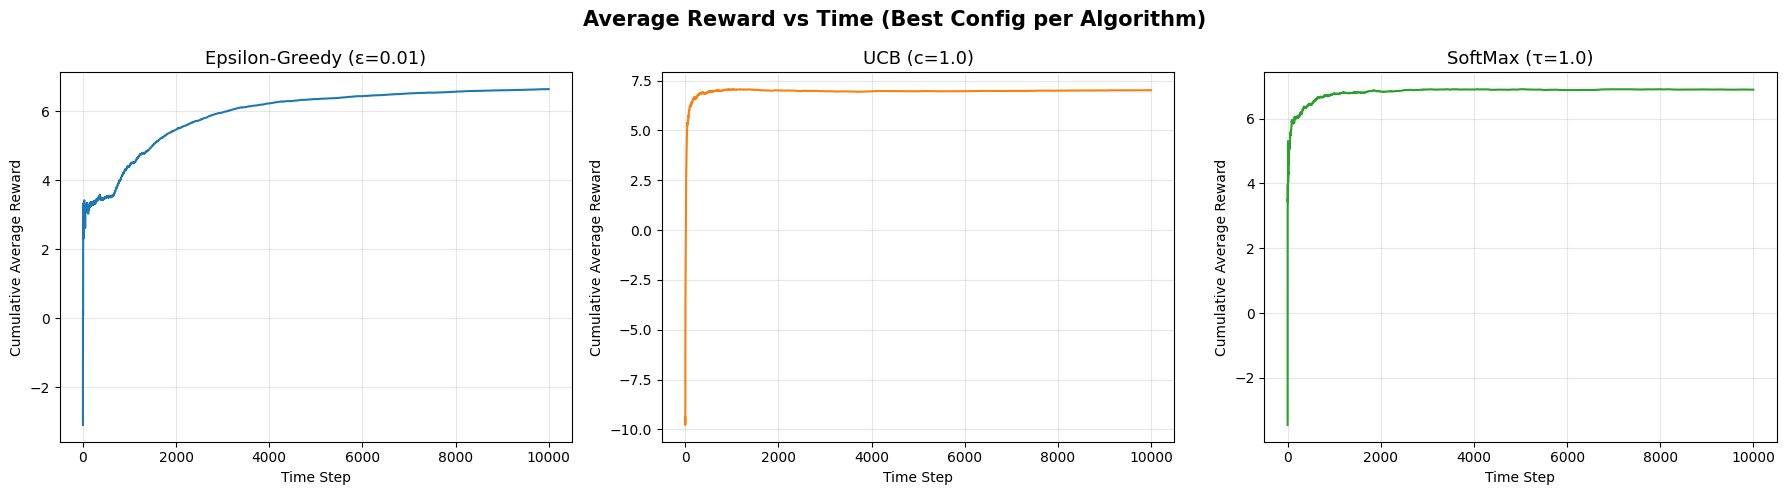

In [ ]:
# --- Plot 1: Average Reward vs Time (Best Hyperparameter per Algorithm) ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Best Epsilon-Greedy
best_eps = max(eg_results, key=lambda k: eg_results[k]['cumulative_avg'][-1])
axes[0].plot(eg_results[best_eps]['cumulative_avg'], color='tab:blue', linewidth=1.5)
axes[0].set_title(f'Epsilon-Greedy (ε={best_eps})', fontsize=13)
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Cumulative Average Reward')
axes[0].grid(True, alpha=0.3)

# Best UCB
best_c = max(ucb_results, key=lambda k: ucb_results[k]['cumulative_avg'][-1])
axes[1].plot(ucb_results[best_c]['cumulative_avg'], color='tab:orange', linewidth=1.5)
axes[1].set_title(f'UCB (c={best_c})', fontsize=13)
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Cumulative Average Reward')
axes[1].grid(True, alpha=0.3)

# Best SoftMax
best_tau = max(sm_results, key=lambda k: sm_results[k]['cumulative_avg'][-1])
axes[2].plot(sm_results[best_tau]['cumulative_avg'], color='tab:green', linewidth=1.5)
axes[2].set_title(f'SoftMax (τ={best_tau})', fontsize=13)
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Cumulative Average Reward')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Average Reward vs Time (Best Config per Algorithm)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

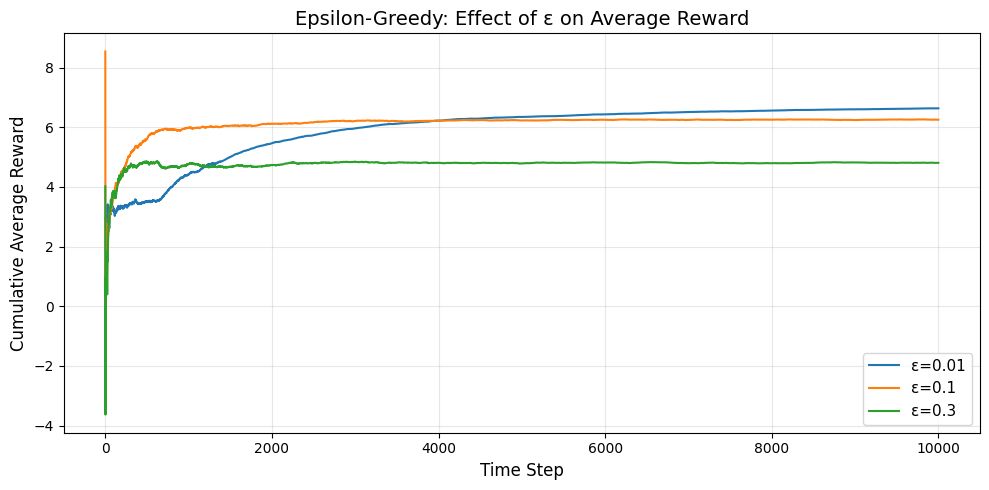

In [ ]:
# --- Plot 2: Hyperparameter Comparison - Epsilon-Greedy ---

fig, ax = plt.subplots(figsize=(10, 5))
for eps in epsilon_values:
    ax.plot(eg_results[eps]['cumulative_avg'], label=f'ε={eps}', linewidth=1.5)
ax.set_title('Epsilon-Greedy: Effect of ε on Average Reward', fontsize=14)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Cumulative Average Reward', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

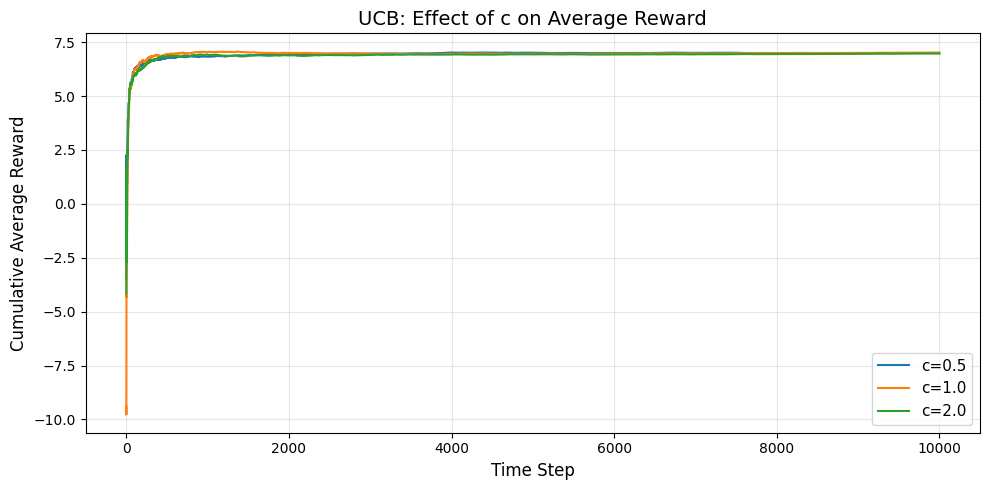

In [ ]:
# --- Plot 3: Hyperparameter Comparison - UCB ---

fig, ax = plt.subplots(figsize=(10, 5))
for c in c_values:
    ax.plot(ucb_results[c]['cumulative_avg'], label=f'c={c}', linewidth=1.5)
ax.set_title('UCB: Effect of c on Average Reward', fontsize=14)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Cumulative Average Reward', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

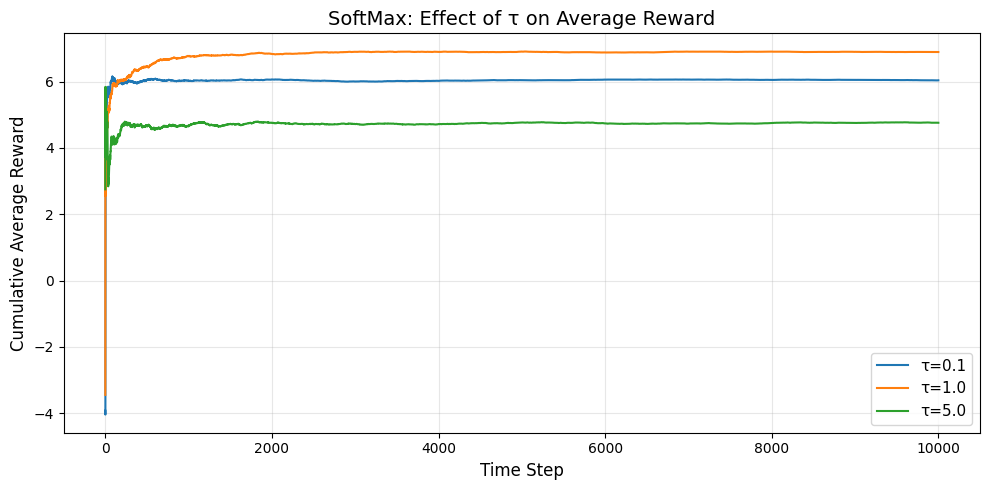

In [ ]:
# --- Plot 4: Hyperparameter Comparison - SoftMax ---

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_values:
    ax.plot(sm_results[tau]['cumulative_avg'], label=f'τ={tau}', linewidth=1.5)
ax.set_title('SoftMax: Effect of τ on Average Reward', fontsize=14)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Cumulative Average Reward', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

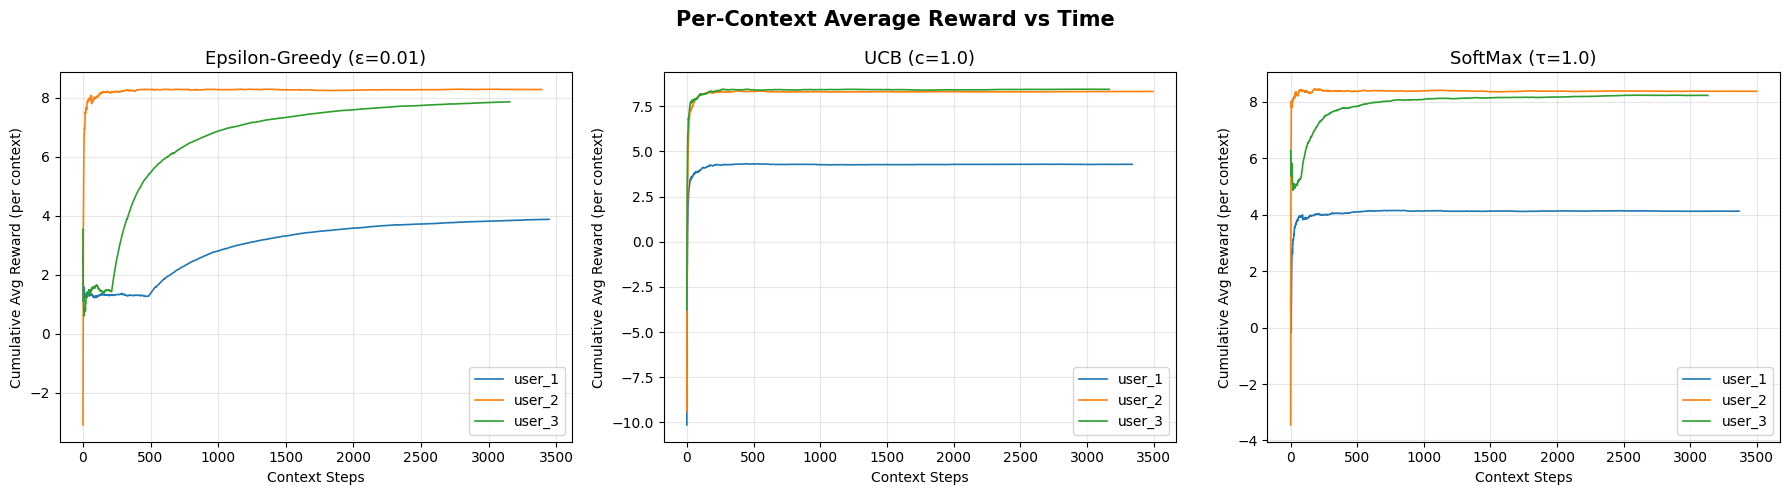

In [ ]:
# --- Plot 5: Per-Context Average Reward (Best Config per Algorithm) ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = [
    f'Epsilon-Greedy (ε={best_eps})',
    f'UCB (c={best_c})',
    f'SoftMax (τ={best_tau})'
]
results_list = [eg_results[best_eps], ucb_results[best_c], sm_results[best_tau]]
colors = ['tab:red', 'tab:blue', 'tab:green']

for idx, (result, title) in enumerate(zip(results_list, titles)):
    ax = axes[idx]
    for user_idx in range(3):
        ctx_avg = result['per_context_avg'][user_idx]
        if len(ctx_avg) > 0:
            ax.plot(ctx_avg, label=f'{user_types[user_idx]}', linewidth=1.2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Context Steps')
    ax.set_ylabel('Cumulative Avg Reward (per context)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Per-Context Average Reward vs Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

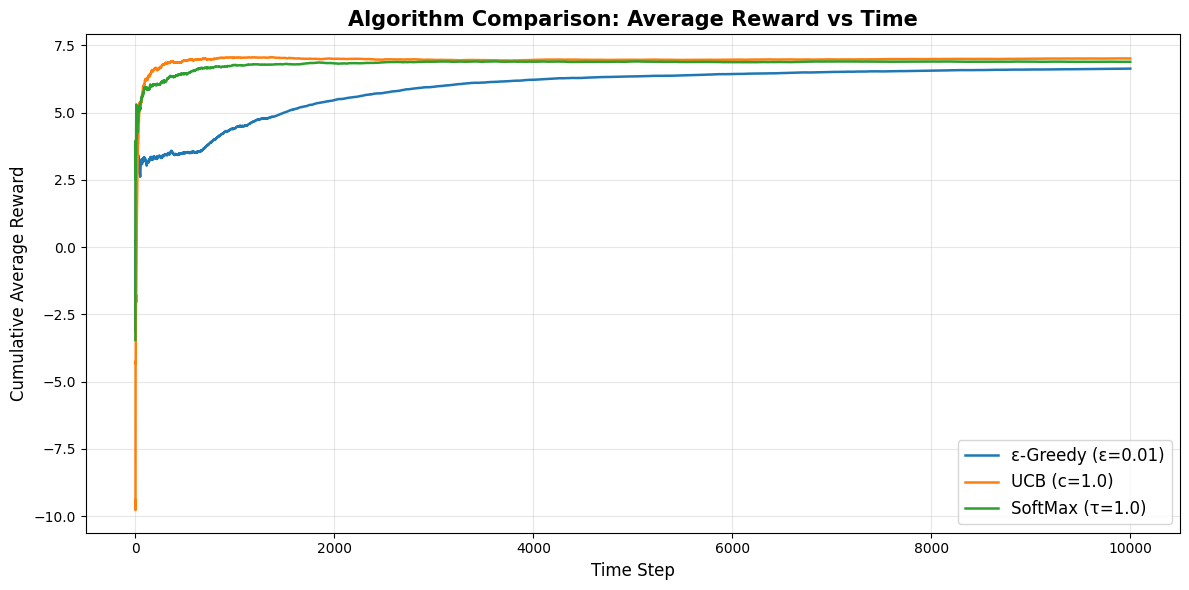

In [ ]:
# --- Plot 6: All Algorithms Comparison (Best Hyperparams) ---

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eg_results[best_eps]['cumulative_avg'], label=f'ε-Greedy (ε={best_eps})', linewidth=1.8, color='tab:blue')
ax.plot(ucb_results[best_c]['cumulative_avg'], label=f'UCB (c={best_c})', linewidth=1.8, color='tab:orange')
ax.plot(sm_results[best_tau]['cumulative_avg'], label=f'SoftMax (τ={best_tau})', linewidth=1.8, color='tab:green')

ax.set_title('Algorithm Comparison: Average Reward vs Time', fontsize=15, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Cumulative Average Reward', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Summary Table & Q-Value Analysis ---

print("=" * 70)
print("SUMMARY: Final Average Rewards (T = 10,000)")
print("=" * 70)

# Collect all results for comparison
summary_rows = []

for eps in epsilon_values:
    summary_rows.append({
        'Algorithm': 'Epsilon-Greedy',
        'Hyperparameter': f'ε={eps}',
        'Final Avg Reward': round(eg_results[eps]['cumulative_avg'][-1], 4)
    })

for c in c_values:
    summary_rows.append({
        'Algorithm': 'UCB',
        'Hyperparameter': f'c={c}',
        'Final Avg Reward': round(ucb_results[c]['cumulative_avg'][-1], 4)
    })

for tau in tau_values:
    summary_rows.append({
        'Algorithm': 'SoftMax',
        'Hyperparameter': f'τ={tau}',
        'Final Avg Reward': round(sm_results[tau]['cumulative_avg'][-1], 4)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# --- Learned Q-Values for Best Configuration ---
print("\n" + "=" * 70)
print("LEARNED Q-VALUES (Best Configuration per Algorithm)")
print("=" * 70)

best_configs = [
    ('Epsilon-Greedy', f'ε={best_eps}', eg_results[best_eps]),
    ('UCB', f'c={best_c}', ucb_results[best_c]),
    ('SoftMax', f'τ={best_tau}', sm_results[best_tau])
]

for algo_name, param, result in best_configs:
    print(f"\n--- {algo_name} ({param}) ---")
    q_df = pd.DataFrame(
        result['Q_values'],
        index=[f'{u}' for u in user_types],
        columns=categories
    )
    print(q_df.round(3).to_string())

    # Show best arm per context
    for user_idx, user in enumerate(user_types):
        best_arm = np.argmax(result['Q_values'][user_idx])
        print(f"  Best arm for {user}: {categories[best_arm]} "
              f"(Q={result['Q_values'][user_idx, best_arm]:.3f}, "
              f"pulled {int(result['N_counts'][user_idx, best_arm])} times)")

SUMMARY: Final Average Rewards (T = 10,000)
     Algorithm Hyperparameter  Final Avg Reward
Epsilon-Greedy         ε=0.01            6.6369
Epsilon-Greedy          ε=0.1            6.2546
Epsilon-Greedy          ε=0.3            4.8087
           UCB          c=0.5            7.0052
           UCB          c=1.0            7.0141
           UCB          c=2.0            6.9720
       SoftMax          τ=0.1            6.0377
       SoftMax          τ=1.0            6.8907
       SoftMax          τ=5.0            4.7570

LEARNED Q-VALUES (Best Configuration per Algorithm)

--- Epsilon-Greedy (ε=0.01) ---
        Entertainment  Education    Tech  Crime
user_1         -4.647      1.381 -11.462  4.368
user_2          8.364      0.388  -3.604 -9.574
user_3          8.392     -4.097   1.393  5.853
  Best arm for user_1: Crime (Q=4.368, pulled 2940 times)
  Best arm for user_2: Entertainment (Q=8.364, pulled 3374 times)
  Best arm for user_3: Entertainment (Q=8.392, pulled 2922 times)

--- UCB

## Final Observations

### 1. Algorithm Comparison

| Algorithm | Strengths | Limitations |
|-----------|-----------|-------------|
| **Epsilon-Greedy** | Simple to implement; stable convergence with low ε | Fixed exploration rate doesn't adapt; may over-explore with high ε |
| **UCB** | Principled exploration (uncertainty-driven); no randomness in arm selection once initialized | Can be slow to converge with high c; assumes stationarity |
| **SoftMax** | Smooth probability-based exploration; respects Q-value differences | Temperature tuning is critical; very low τ ≈ greedy, very high τ ≈ random |

### 2. Hyperparameter Effects

- **Epsilon-Greedy**: Lower ε (e.g., 0.01) tends to converge faster to the best arm but risks missing better arms early. Higher ε (e.g., 0.3) explores more but wastes pulls on sub-optimal arms.
- **UCB**: Lower c focuses on exploitation while higher c widens confidence bounds, leading to more exploration. The standard c=2 typically provides a balanced trade-off.
- **SoftMax**: Low temperature (τ=0.1) behaves nearly greedy, converging fast if initial estimates are good. High temperature (τ=5.0) produces near-uniform selection, slowing convergence.

### 3. Context Matters

Different user types may have different optimal arms (news categories). The contextual bandit approach allows learning **separate policies per user type**, which is more effective than a single global bandit.

### 4. Key Takeaways

- All three algorithms converge to reasonable policies given enough time steps.
- The **best algorithm depends on the problem**: if fast convergence is needed, low-exploration strategies work; if the reward landscape is complex, more exploration helps.
- **UCB** tends to be the most principled as it naturally balances exploration and exploitation without random exploration.
- Using predicted user categories as **context** enables personalized recommendations — each user type gets a tailored news category recommendation.